# Case Olist — Notebook 01: Coleta, Organização e Preparação dos Dados

**Aluna:** Gabriela Piccinini  
**Curso:** MBA em Gestão Estratégica, Excelência Operacional e Métodos Ágeis — Frons Educação  
**Disciplina:** Análise de dados para tomada de decisões estratégicas (MBAGESTAO) — Professor Bruno César  
**Entregável 2:** Modelagem e preparação dos dados

---

## Objetivo

Transformar as 9 tabelas públicas da Olist em **duas bases analíticas prontas para responder às três perguntas do CEO**:

1. **Onde perdemos dinheiro?**
2. **Onde investir?**
3. **O que o cliente está dizendo?**

| Base gerada | Uma linha por | Para que serve |
|---|---|---|
| `base_pedidos.csv` | pedido | prazos, atrasos, avaliações, receita e pagamento |
| `base_itens.csv` | item vendido | categorias, vendedores, frete e distância |

## Etapas deste notebook

1. Configuração e carregamento das 9 tabelas
2. Diagnóstico de qualidade (tamanho, nulos, duplicidades)
3. Tratamento dos dados
4. Junção das tabelas (modelo de dados)
5. Criação das variáveis derivadas
6. Checagens de consistência
7. Recálculo dos indicadores do Entregável 1
8. Exportação das bases tratadas

## 1. Configuração e carregamento

**Como rodar:** este notebook procura os arquivos CSV da Olist na pasta `data/raw/`. Se não encontrar, baixa automaticamente do Kaggle (dataset público *olistbr/brazilian-ecommerce*).

No Google Colab, basta executar todas as células em ordem (menu *Ambiente de execução → Executar tudo*).

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

ARQUIVOS = {
    'pedidos':     'olist_orders_dataset.csv',
    'itens':       'olist_order_items_dataset.csv',
    'pagamentos':  'olist_order_payments_dataset.csv',
    'avaliacoes':  'olist_order_reviews_dataset.csv',
    'clientes':    'olist_customers_dataset.csv',
    'vendedores':  'olist_sellers_dataset.csv',
    'produtos':    'olist_products_dataset.csv',
    'traducao':    'product_category_name_translation.csv',
    'geolocalizacao': 'olist_geolocation_dataset.csv',
}

def localizar_pasta_dados():
    candidatos = [os.environ.get('OLIST_DATA_DIR', ''), 'data/raw', '../data/raw', '/content/data/raw', '/content']
    for pasta in candidatos:
        if pasta and os.path.exists(os.path.join(pasta, ARQUIVOS['pedidos'])):
            return pasta
    # Plano B: download automático do Kaggle
    try:
        try:
            import kagglehub
        except ImportError:
            import subprocess, sys
            subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'], check=True)
            import kagglehub
        return kagglehub.dataset_download('olistbr/brazilian-ecommerce')
    except Exception as erro:
        raise FileNotFoundError('Arquivos da Olist não encontrados. Coloque os CSVs em data/raw/.') from erro

PASTA = localizar_pasta_dados()
# As bases tratadas são salvas ao lado da pasta de dados brutos (data/processed)
if os.path.basename(os.path.normpath(PASTA)) == 'raw':
    PASTA_SAIDA = os.path.join(os.path.dirname(os.path.normpath(PASTA)), 'processed')
else:
    PASTA_SAIDA = 'data/processed'
print('Lendo dados de:', PASTA)
print('Bases tratadas serão salvas em:', PASTA_SAIDA)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Lendo dados de: /kaggle/input/brazilian-ecommerce
Bases tratadas serão salvas em: data/processed


In [2]:
colunas_data = {
    'pedidos': ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
                'order_delivered_customer_date', 'order_estimated_delivery_date'],
    'itens': ['shipping_limit_date'],
    'avaliacoes': ['review_creation_date', 'review_answer_timestamp'],
}

dados = {}
for nome, arquivo in ARQUIVOS.items():
    caminho = os.path.join(PASTA, arquivo)
    if not os.path.exists(caminho):
        print(f'ATENÇÃO: {arquivo} não encontrado — tabela "{nome}" ficará de fora.')
        continue
    dados[nome] = pd.read_csv(caminho, parse_dates=colunas_data.get(nome, []), encoding='utf-8-sig')

print(f'{len(dados)} de {len(ARQUIVOS)} tabelas carregadas.')

9 de 9 tabelas carregadas.


## 2. Diagnóstico de qualidade

Antes de tratar, olhamos o tamanho de cada tabela, quantas células estão vazias e se há linhas repetidas.

In [3]:
diagnostico = pd.DataFrame({
    'linhas': {n: len(df) for n, df in dados.items()},
    'colunas': {n: df.shape[1] for n, df in dados.items()},
    'celulas_vazias': {n: int(df.isna().sum().sum()) for n, df in dados.items()},
    'linhas_duplicadas': {n: int(df.duplicated().sum()) for n, df in dados.items()},
})
diagnostico

,linhas,colunas,celulas_vazias,linhas_duplicadas
pedidos,99441,8,4908,0
itens,112650,7,0,0
pagamentos,103886,5,0,0
avaliacoes,99224,7,145903,0
clientes,99441,5,0,0
vendedores,3095,4,0,0
produtos,32951,9,2448,0
traducao,71,2,0,0
geolocalizacao,1000163,5,0,261831


In [4]:
# Onde estão os campos vazios (apenas colunas com algum vazio)
for nome, df in dados.items():
    vazios = df.isna().sum()
    vazios = vazios[vazios > 0]
    if len(vazios):
        print(f'\n{nome.upper()}')
        print((vazios.to_frame('vazios').assign(percentual=lambda x: 100 * x.vazios / len(df))).round(1))


PEDIDOS
                               vazios  percentual
order_approved_at                 160        0.20
order_delivered_carrier_date     1783        1.80
order_delivered_customer_date    2965        3.00

AVALIACOES
                        vazios  percentual
review_comment_title     87656       88.30
review_comment_message   58247       58.70

PRODUTOS
                            vazios  percentual
product_category_name          610        1.90
product_name_lenght            610        1.90
product_description_lenght     610        1.90
product_photos_qty             610        1.90
product_weight_g                 2        0.00
product_length_cm                2        0.00
product_height_cm                2        0.00
product_width_cm                 2        0.00


**Leitura do diagnóstico**

- **Pedidos:** as datas vazias de entrega correspondem, em quase todos os casos, a pedidos cancelados, indisponíveis ou ainda em trânsito. Não é erro: é o retrato do processo.
- **Avaliações:** título e comentário são opcionais para o cliente, por isso a maioria está vazia. A nota (1 a 5) está sempre preenchida.
- **Produtos:** 610 produtos não têm categoria informada.
- **Geolocalização:** tem muitas linhas repetidas, porque cada CEP aparece com várias coordenadas.

## 3. Tratamento dos dados

| Problema | Decisão tomada | Motivo |
|---|---|---|
| Meses com poucos pedidos (2016, set e out/2018) | Excluídos da análise | Distorceriam médias e tendências |
| Pedidos sem data de entrega | Mantidos na base; excluídos só dos cálculos de prazo | Continuam valendo para cancelamento e receita |
| Pedido com mais de uma avaliação | Mantida apenas a avaliação mais recente | Uma opinião por pedido |
| Produto sem categoria | Categoria = `sem_categoria` | Evita perder receita nas somas |
| Nomes de categoria em português técnico | Traduzidos e padronizados | Leitura mais fácil nos gráficos |
| Várias coordenadas por CEP | Uma coordenada média por prefixo de CEP | Permite calcular distância vendedor → cliente |

In [5]:
# 3.1 Período de análise: janeiro/2017 a agosto/2018 (meses completos)
INICIO, FIM = '2017-01-01', '2018-09-01'
pedidos = dados['pedidos'].copy()
total_original = len(pedidos)
pedidos = pedidos[(pedidos.order_purchase_timestamp >= INICIO) & (pedidos.order_purchase_timestamp < FIM)]
print(f'Pedidos no período: {len(pedidos):,} de {total_original:,} ({100*len(pedidos)/total_original:.1f}%)')

Pedidos no período: 99,092 de 99,441 (99.6%)


In [6]:
# 3.2 Avaliações: uma por pedido (a mais recente)
avaliacoes = (dados['avaliacoes']
              .sort_values('review_answer_timestamp')
              .drop_duplicates('order_id', keep='last'))
avaliacoes['tem_comentario'] = avaliacoes.review_comment_message.notna()
print('Pedidos com avaliação:', f'{len(avaliacoes):,}')

Pedidos com avaliação: 98,673


In [7]:
# 3.3 Produtos: categoria preenchida e traduzida
produtos = dados['produtos'].copy()
traducao = dados['traducao'].copy()
traducao.columns = [c.replace('\ufeff', '') for c in traducao.columns]
produtos['product_category_name'] = produtos.product_category_name.fillna('sem_categoria')
produtos = produtos.merge(traducao, on='product_category_name', how='left')
produtos['categoria'] = (produtos.product_category_name
                         .str.replace('_', ' ')
                         .str.capitalize())
print('Categorias distintas:', produtos.categoria.nunique())

Categorias distintas: 74


In [8]:
# 3.4 Geolocalização: uma coordenada média por prefixo de CEP
if 'geolocalizacao' in dados:
    geo = (dados['geolocalizacao']
           .groupby('geolocation_zip_code_prefix', as_index=False)
           .agg(lat=('geolocation_lat', 'mean'), lng=('geolocation_lng', 'mean')))
    print(f'{len(dados["geolocalizacao"]):,} linhas reduzidas para {len(geo):,} prefixos de CEP')
else:
    geo = None
    print('Tabela de geolocalização ausente: distância não será calculada.')

1,000,163 linhas reduzidas para 19,015 prefixos de CEP


## 4. Junção das tabelas (modelo de dados)

O pedido é o centro do modelo. As demais tabelas se ligam a ele por chaves de identificação:

```
clientes ──(customer_id)──┐
                          ├── PEDIDOS ──(order_id)── itens ──(product_id)── produtos ── tradução
avaliações ─(order_id)────┤                           └──(seller_id)── vendedores
pagamentos ─(order_id)────┘
geolocalização ──(prefixo do CEP)── clientes e vendedores
```

**Cuidado importante:** um pedido pode ter vários itens e vários pagamentos. Por isso, itens e pagamentos são **resumidos por pedido antes da junção**. Sem esse passo, o valor de um pedido seria contado várias vezes.

In [9]:
# 4.1 Resumo dos itens por pedido
itens = dados['itens']
itens_por_pedido = itens.groupby('order_id').agg(
    qtd_itens=('order_item_id', 'count'),
    valor_produtos=('price', 'sum'),
    valor_frete=('freight_value', 'sum'),
    qtd_vendedores=('seller_id', 'nunique'),
).reset_index()

# 4.2 Resumo dos pagamentos por pedido
pagamentos = dados['pagamentos']
pag_por_pedido = pagamentos.groupby('order_id').agg(
    valor_pago=('payment_value', 'sum'),
    parcelas=('payment_installments', 'max'),
    qtd_formas_pagamento=('payment_type', 'nunique'),
).reset_index()
forma_principal = (pagamentos.sort_values('payment_value', ascending=False)
                   .drop_duplicates('order_id')[['order_id', 'payment_type']]
                   .rename(columns={'payment_type': 'forma_pagamento'}))
pag_por_pedido = pag_por_pedido.merge(forma_principal, on='order_id', how='left')

In [10]:
# 4.3 Base de pedidos (uma linha por pedido)
base_pedidos = (pedidos
    .merge(dados['clientes'], on='customer_id', how='left')
    .merge(itens_por_pedido, on='order_id', how='left')
    .merge(pag_por_pedido, on='order_id', how='left')
    .merge(avaliacoes[['order_id', 'review_score', 'tem_comentario', 'review_comment_message']],
           on='order_id', how='left'))

assert base_pedidos.order_id.is_unique, 'Erro: pedido duplicado após a junção'
print(f'base_pedidos: {base_pedidos.shape[0]:,} linhas x {base_pedidos.shape[1]} colunas')

base_pedidos: 99,092 linhas x 23 colunas


In [11]:
# 4.4 Base de itens (uma linha por item vendido)
base_itens = (itens
    .merge(pedidos[['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
                    'order_delivered_customer_date', 'order_estimated_delivery_date']],
           on='order_id', how='inner')
    .merge(dados['clientes'][['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
                              'customer_city', 'customer_state']], on='customer_id', how='left')
    .merge(produtos[['product_id', 'product_category_name', 'product_category_name_english',
                     'categoria', 'product_weight_g']], on='product_id', how='left')
    .merge(dados['vendedores'], on='seller_id', how='left'))
print(f'base_itens: {base_itens.shape[0]:,} linhas x {base_itens.shape[1]} colunas')

base_itens: 112,279 linhas x 23 colunas


## 5. Variáveis derivadas

| Variável | Como é calculada | Pergunta do CEO |
|---|---|---|
| `dias_entrega` | entrega ao cliente − data da compra | Onde perdemos dinheiro? |
| `prazo_prometido_dias` | data estimada − data da compra | Onde perdemos dinheiro? |
| `dias_atraso` | entrega ao cliente − data estimada (positivo = atraso) | Onde perdemos dinheiro? |
| `atrasado` | verdadeiro quando `dias_atraso` > 0 | Onde perdemos dinheiro? |
| `receita_bruta` | valor dos produtos + frete | Onde investir? |
| `receita_liquida` | receita bruta − frete (valor que fica com a operação) | Onde investir? |
| `peso_frete` | frete ÷ receita bruta | Onde perdemos dinheiro? |
| `regiao` | estado do cliente agrupado nas 5 regiões | Todas |
| `ano_mes` | mês da compra | Todas |
| `avaliacao_ruim` / `avaliacao_otima` | nota 1–2 / nota 5 | O que o cliente diz? |
| `distancia_km` | distância em linha reta vendedor → cliente | Onde perdemos dinheiro? |

In [12]:
REGIOES = {
    'Sudeste': ['SP', 'RJ', 'MG', 'ES'],
    'Sul': ['PR', 'SC', 'RS'],
    'Centro-Oeste': ['DF', 'GO', 'MT', 'MS'],
    'Nordeste': ['BA', 'PE', 'CE', 'MA', 'PB', 'RN', 'AL', 'SE', 'PI'],
    'Norte': ['AM', 'PA', 'AC', 'RO', 'RR', 'AP', 'TO'],
}
estado_para_regiao = {uf: reg for reg, ufs in REGIOES.items() for uf in ufs}

bp = base_pedidos
compra = bp.order_purchase_timestamp
bp['dias_entrega'] = (bp.order_delivered_customer_date - compra).dt.total_seconds() / 86400
bp['prazo_prometido_dias'] = (bp.order_estimated_delivery_date - compra).dt.total_seconds() / 86400
bp['dias_atraso'] = (bp.order_delivered_customer_date.dt.normalize() - bp.order_estimated_delivery_date).dt.days
bp['atrasado'] = np.where(bp.dias_atraso.notna(), bp.dias_atraso > 0, np.nan)
bp['receita_bruta'] = bp.valor_produtos + bp.valor_frete
bp['receita_liquida'] = bp.valor_produtos
bp['peso_frete'] = bp.valor_frete / bp.receita_bruta
bp['regiao'] = bp.customer_state.map(estado_para_regiao)
bp['ano_mes'] = compra.dt.to_period('M').astype(str)
bp['entregue'] = (bp.order_status == 'delivered') & bp.order_delivered_customer_date.notna()
bp['cancelado'] = bp.order_status.isin(['canceled', 'unavailable'])
bp['avaliacao_ruim'] = bp.review_score <= 2
bp['avaliacao_otima'] = bp.review_score == 5

bp[['dias_entrega', 'prazo_prometido_dias', 'dias_atraso', 'receita_bruta', 'peso_frete']].describe().T

,count,mean,std,min,25%,50%,75%,max
dias_entrega,"96,204.00",12.54,9.53,0.53,6.76,10.21,15.68,209.63
prazo_prometido_dias,"99,092.00",23.67,8.65,2.01,18.32,23.22,28.39,155.14
dias_atraso,"96,204.00",-11.81,10.09,-147.00,-17.00,-12.00,-7.00,188.00
receita_bruta,"98,353.00",160.51,220.51,9.59,61.96,105.28,176.81,"13,664.08"
peso_frete,"98,353.00",0.21,0.13,0.00,0.12,0.18,0.28,0.96


In [13]:
# Distância vendedor → cliente (fórmula de Haversine), quando a geolocalização estiver disponível
def distancia_km(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lng2 - lng1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

bi = base_itens
bi['regiao_cliente'] = bi.customer_state.map(estado_para_regiao)
bi['regiao_vendedor'] = bi.seller_state.map(estado_para_regiao)
bi['mesmo_estado'] = bi.customer_state == bi.seller_state
bi['peso_frete'] = bi.freight_value / (bi.price + bi.freight_value)
bi['ano_mes'] = bi.order_purchase_timestamp.dt.to_period('M').astype(str)

if geo is not None:
    g_cli = geo.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix', 'lat': 'lat_cli', 'lng': 'lng_cli'})
    g_ven = geo.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_code_prefix', 'lat': 'lat_ven', 'lng': 'lng_ven'})
    bi = bi.merge(g_cli, on='customer_zip_code_prefix', how='left').merge(g_ven, on='seller_zip_code_prefix', how='left')
    bi['distancia_km'] = distancia_km(bi.lat_ven, bi.lng_ven, bi.lat_cli, bi.lng_cli)
    print(f'Distância calculada para {bi.distancia_km.notna().mean():.1%} dos itens')
base_itens = bi

Distância calculada para 99.5% dos itens


## 6. Checagens de consistência

Três perguntas simples para confiar na base:

1. O valor pago bate com produtos + frete?
2. Existem prazos negativos ou absurdos?
3. Todos os pedidos entregues têm data de entrega?

In [14]:
dif = (bp.valor_pago - bp.receita_bruta).abs()
print(f'Pedidos em que valor pago ≠ produtos + frete (diferença > R$ 1): {(dif > 1).mean():.1%}')
print('  → diferenças vêm de juros de parcelamento e vouchers; usamos produtos + frete como receita.')
print(f'Pedidos com prazo de entrega negativo: {(bp.dias_entrega < 0).sum()}')
print(f'Pedidos entregues em mais de 60 dias: {(bp.dias_entrega > 60).sum()} (mantidos: são casos reais e extremos)')
print(f'Pedidos "entregues" sem data de entrega: {((bp.order_status=="delivered") & bp.order_delivered_customer_date.isna()).sum()} (excluídos só dos cálculos de prazo)')

Pedidos em que valor pago ≠ produtos + frete (diferença > R$ 1): 0.2%
  → diferenças vêm de juros de parcelamento e vouchers; usamos produtos + frete como receita.
Pedidos com prazo de entrega negativo: 0
Pedidos entregues em mais de 60 dias: 303 (mantidos: são casos reais e extremos)
Pedidos "entregues" sem data de entrega: 8 (excluídos só dos cálculos de prazo)


## 7. Recálculo dos indicadores do Entregável 1

Os mesmos números do mapa de indicadores, agora gerados a partir da base tratada. Isso garante que o board e o documento de indicadores falem a mesma língua.

In [15]:
ent = bp[bp.entregue]
clientes_pedidos = ent.groupby('customer_unique_id').size()
kpis = pd.Series({
    'Taxa de atraso na entrega': f'{ent.atrasado.mean():.1%}',
    'Peso do frete': f'{ent.valor_frete.sum() / ent.receita_bruta.sum():.1%}',
    'Perda por cancelamento': f'{bp.cancelado.mean():.1%}',
    'Receita total (produtos + frete)': f'R$ {ent.receita_bruta.sum()/1e6:.1f} milhões',
    'Ticket médio': f'R$ {ent.receita_bruta.mean():.0f}',
    'Taxa de recompra': f'{(clientes_pedidos > 1).mean():.1%}',
    'Satisfação líquida (aproximação do NPS)': f'{100*(ent.avaliacao_otima.mean() - ent.avaliacao_ruim.mean()):+.0f}',
    'Nota média': f'{ent.review_score.mean():.2f}',
})
kpis.to_frame('Linha de base')

,Linha de base
Taxa de atraso na entrega,6.8%
Peso do frete,14.3%
Perda por cancelamento,1.2%
Receita total (produtos + frete),R$ 15.4 milhões
Ticket médio,R$ 160
Taxa de recompra,3.0%
Satisfação líquida (aproximação do NPS),+46
Nota média,4.16


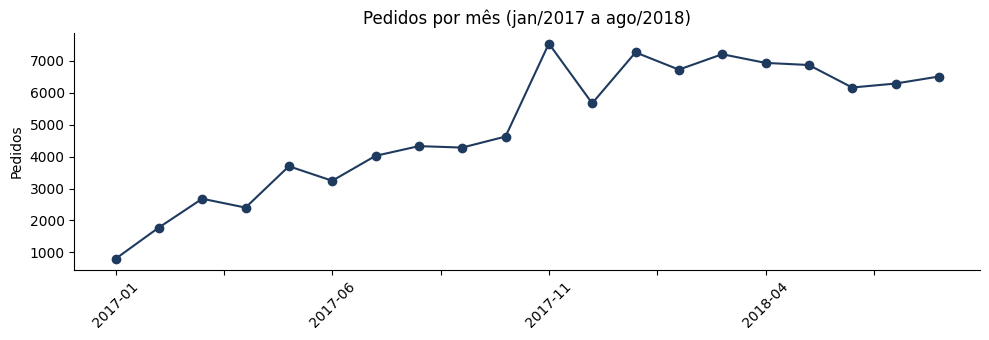

In [16]:
# Visão rápida: pedidos por mês no período analisado
serie = bp.groupby('ano_mes').size()
fig, ax = plt.subplots(figsize=(10, 3.5))
serie.plot(ax=ax, color='#1F3A5F', marker='o')
ax.set_title('Pedidos por mês (jan/2017 a ago/2018)')
ax.set_xlabel(''); ax.set_ylabel('Pedidos')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 8. Exportação das bases tratadas

As bases ficam em `data/processed/` e alimentam o notebook de análise exploratória (Entregável 3).

In [17]:
os.makedirs(PASTA_SAIDA, exist_ok=True)
base_pedidos.to_csv(os.path.join(PASTA_SAIDA, 'base_pedidos.csv'), index=False)
base_itens.to_csv(os.path.join(PASTA_SAIDA, 'base_itens.csv'), index=False)
print('Arquivos salvos em', PASTA_SAIDA)

Arquivos salvos em data/processed


## Limitações registradas nesta etapa

- O dataset termina em 2018 e não capta mudanças do comércio eletrônico após a pandemia.
- Não há custo dos produtos nem gasto com marketing: margem de lucro e custo de aquisição de cliente não podem ser calculados.
- A satisfação líquida é uma adaptação do NPS feita sobre a nota de 1 a 5.
- A distância vendedor → cliente é em linha reta, não a rota real percorrida.
- Os comentários das avaliações estão em português e exigirão tratamento de texto específico na etapa exploratória.